# 1. Understand the Dataset

In [15]:
# 1.1 Import the dataset
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [16]:
df = pd.read_csv('customer_analysis.csv')

In [17]:
# 1.2 Visualize the dataset
df.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01/01/2016 12:55:15 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01/01/2016 01:26:57 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01/01/2016 04:51:03 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 11:57:46 PM,01/01/2016 07:43:13 AM,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 11:56:58 PM,01/01/2016 03:24:42 AM,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


In [29]:
# 1.3 Print columns
df.columns

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Intersection Street 1', 'Intersection Street 2', 'Address Type',
       'City', 'Landmark', 'Facility Type', 'Status', 'Due Date',
       'Resolution Description', 'Resolution Action Updated Date',
       'Community Board', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough',
       'School Name', 'School Number', 'School Region', 'School Code',
       'School Phone Number', 'School Address', 'School City', 'School State',
       'School Zip', 'School Not Found', 'School or Citywide Complaint',
       'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location',
       'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp',
       'Bridge Highway Segment', 'Garage Lot Name', 'Ferry 

In [18]:
# 1.4 Identify the shape of the dataset 
df.shape

(364558, 53)

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
# 1.5 Identify the variables with null values
df.isnull().info()

<class 'pandas.DataFrame'>
RangeIndex: 364558 entries, 0 to 364557
Data columns (total 53 columns):
 #   Column                          Non-Null Count   Dtype
---  ------                          --------------   -----
 0   Unique Key                      364558 non-null  bool 
 1   Created Date                    364558 non-null  bool 
 2   Closed Date                     364558 non-null  bool 
 3   Agency                          364558 non-null  bool 
 4   Agency Name                     364558 non-null  bool 
 5   Complaint Type                  364558 non-null  bool 
 6   Descriptor                      364558 non-null  bool 
 7   Location Type                   364558 non-null  bool 
 8   Incident Zip                    364558 non-null  bool 
 9   Incident Address                364558 non-null  bool 
 10  Street Name                     364558 non-null  bool 
 11  Cross Street 1                  364558 non-null  bool 
 12  Cross Street 2                  364558 non-null  bool 


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 364558 entries, 0 to 364557
Data columns (total 53 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Unique Key                      364558 non-null  int64  
 1   Created Date                    364558 non-null  str    
 2   Closed Date                     362177 non-null  str    
 3   Agency                          364558 non-null  str    
 4   Agency Name                     364558 non-null  str    
 5   Complaint Type                  364558 non-null  str    
 6   Descriptor                      358057 non-null  str    
 7   Location Type                   364425 non-null  str    
 8   Incident Zip                    361560 non-null  float64
 9   Incident Address                312859 non-null  str    
 10  Street Name                     312859 non-null  str    
 11  Cross Street 1                  307370 non-null  str    
 12  Cross Street 2             

# 2.Exploratory Data Analysis (EDA)

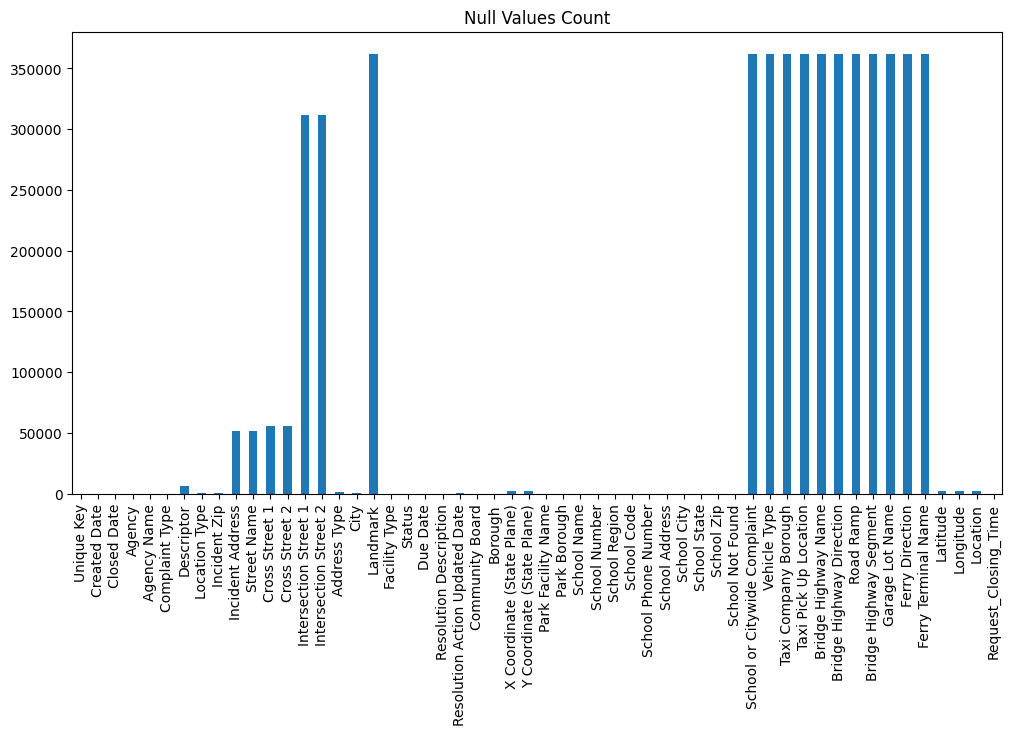

In [34]:
# 2.1Draw a frequency plot to show the number of null values in each column of the DataFrame 
df.isnull().sum().plot(kind='bar', figsize=(12,6))

plt.title("Null Values Count")
plt.xticks(rotation=90)   # rotate x-axis labels
plt.show()

In [35]:
# 2.2 Missing value treatment
# 2.2.1 Remove records where "Closed Date" is null
df = df.dropna(subset=['Closed Date'])

In [36]:
# 2.3 Convert "Created Date" and "Closed Date" to datetime format
df['Created Date'] = pd.to_datetime(df['Created Date'])
df['Closed Date'] = pd.to_datetime(df['Closed Date'])
df.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location,Request_Closing_Time
0,32310363,2015-12-31 23:59:45,2016-01-01 00:55:15,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)",0 days 00:55:30
1,32309934,2015-12-31 23:59:44,2016-01-01 01:26:57,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)",0 days 01:27:13
2,32309159,2015-12-31 23:59:29,2016-01-01 04:51:03,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)",0 days 04:51:34
3,32305098,2015-12-31 23:57:46,2016-01-01 07:43:13,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)",0 days 07:45:27
4,32306529,2015-12-31 23:56:58,2016-01-01 03:24:42,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)",0 days 03:27:44


In [37]:
# 2.3.1Create a new column 'Request_Closing_Time' as the difference between Closed Date and Created Date
df['Request_Closing_Time'] = df ['Closed Date'] - df['Created Date']
df['Request_Closing_Time']


0        0 days 00:55:30
1        0 days 01:27:13
2        0 days 04:51:34
3        0 days 07:45:27
4        0 days 03:27:44
               ...      
364553   0 days 10:17:47
364554   0 days 02:20:34
364555   0 days 00:19:03
364556   0 days 02:40:53
364557   0 days 02:47:00
Name: Request_Closing_Time, Length: 362177, dtype: timedelta64[us]

In [39]:
# 2.3.2Convert the calculated date to seconds to get a better representation 
df['Request_Closing_Time'] = df['Request_Closing_Time'].dt.total_seconds()

In [43]:
# 2.3.3 View the descriptive statistics for the newly created column
df['Request_Closing_Time'].describe()

count    3.621770e+05
mean     1.511330e+04
std      2.110255e+04
min      6.100000e+01
25%      4.533000e+03
50%      9.616000e+03
75%      1.887800e+04
max      2.134342e+06
Name: Request_Closing_Time, dtype: float64

In [44]:
# 2.3.4Check the number of null values in the Complaint_Type and City columns 
df[['Complaint Type', 'City']].isnull().sum()

Complaint Type      0
City              674
dtype: int64

In [46]:
# 2.3.5Impute the NA value with Unknown City 
df['City'].fillna("Unknown City", inplace=True)
df['City']

0                 NEW YORK
1                  ASTORIA
2                    BRONX
3                    BRONX
4                 ELMHURST
                ...       
364553           WOODHAVEN
364554               BRONX
364555            NEW YORK
364556               BRONX
364557    SOUTH OZONE PARK
Name: City, Length: 362177, dtype: str

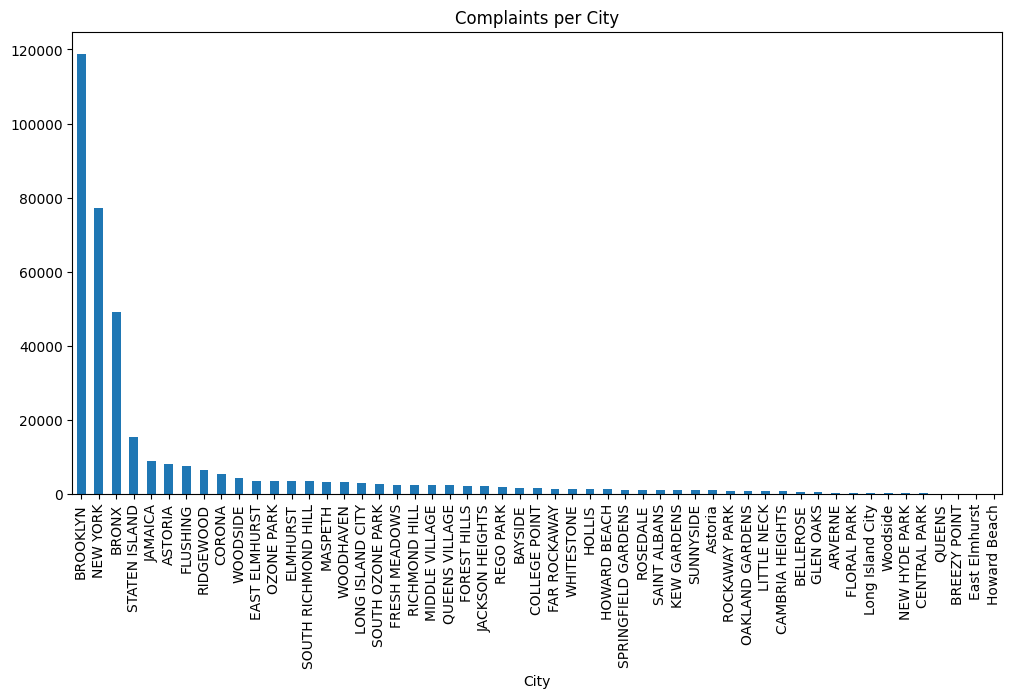

In [48]:
# 2.3.6 Draw a frequency plot for the complaints in each city 
df['City'].value_counts().plot(kind='bar', figsize=(12,6))
plt.title("Complaints per City")
plt.show()

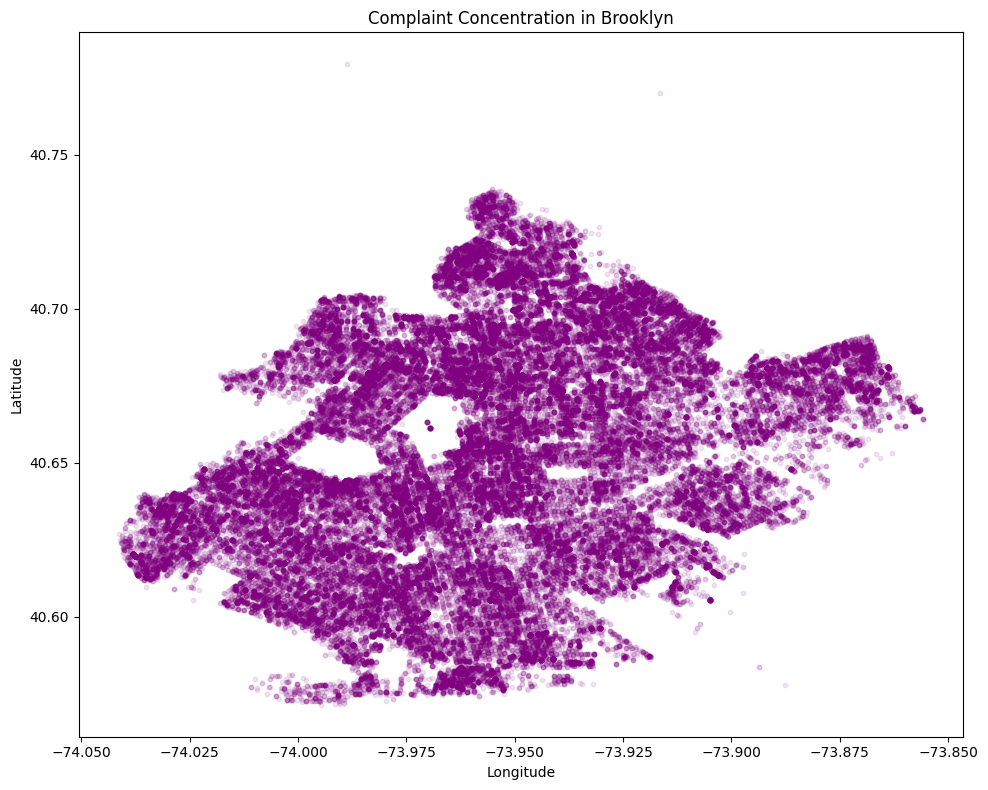

In [69]:
# 2.3.7Create a scatter and hexbin plot of the concentration of complaints across Brooklyn 
brooklyn_data = df[df['City'].str.upper() == 'BROOKLYN'].dropna(subset=['Latitude', 'Longitude'])

# Scatter plot for complaint concentration in Brooklyn (using latitude & longitude)
plt.figure(figsize=(10, 8))
plt.scatter(brooklyn_data['Longitude'], brooklyn_data['Latitude'], alpha=0.1, s=10, c='purple')
plt.title('Complaint Concentration in Brooklyn')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()


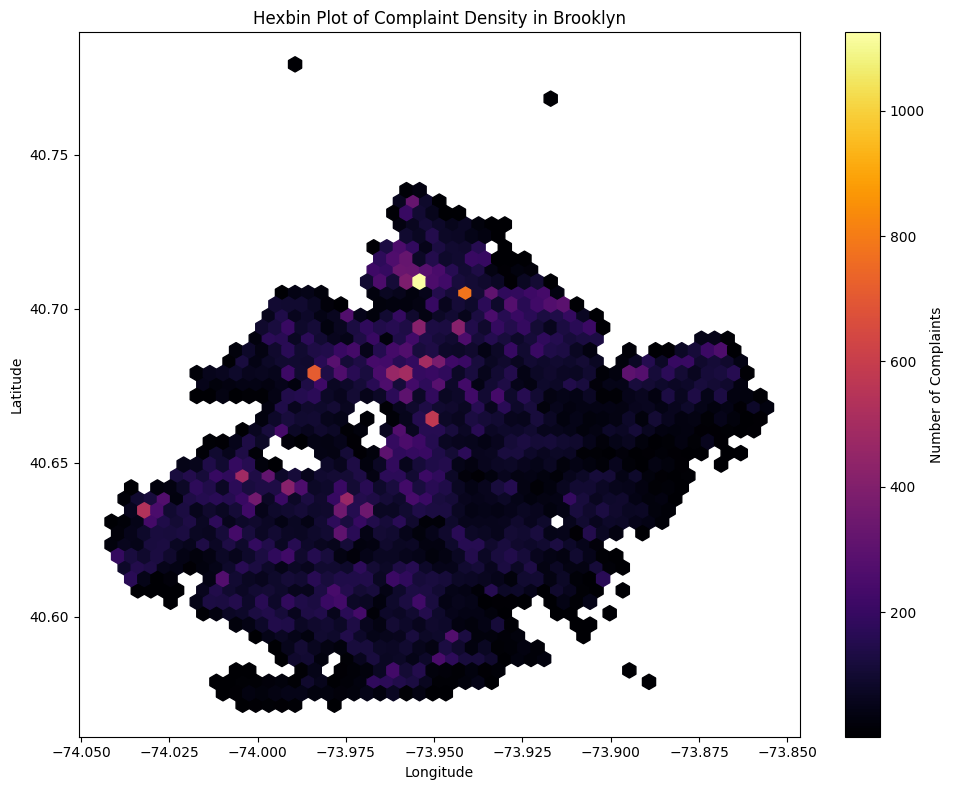

In [70]:
# Hexbin plot for density visualization (Optional but recommended)
plt.figure(figsize=(10, 8))
plt.hexbin(brooklyn_data['Longitude'], brooklyn_data['Latitude'], gridsize=50, cmap='inferno', mincnt=1)
plt.colorbar(label='Number of Complaints')
plt.title('Hexbin Plot of Complaint Density in Brooklyn')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()


# 3.Major Types of Complaints

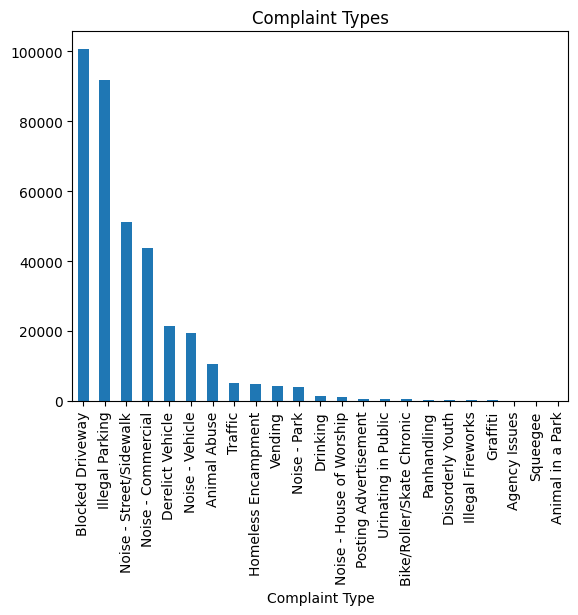

In [51]:
# 3.1Plot a bar graph to show the types of complaints 
df['Complaint Type'].value_counts().plot(kind = 'bar')
plt.title("Complaint Types")
plt.show()

In [53]:
# 3.2Check the frequency of various types of complaints for New York City 
nyc = df[df['City'] == 'NEW YORK']
nyc['Complaint Type'].value_counts()

Complaint Type
Noise - Street/Sidewalk      22245
Noise - Commercial           18686
Illegal Parking              14549
Noise - Vehicle               6294
Homeless Encampment           3060
Blocked Driveway              2705
Vending                       2638
Animal Abuse                  1941
Traffic                       1769
Noise - Park                  1243
Derelict Vehicle               695
Drinking                       321
Urinating in Public            264
Bike/Roller/Skate Chronic      254
Noise - House of Worship       222
Panhandling                    206
Disorderly Youth                81
Posting Advertisement           49
Illegal Fireworks               38
Graffiti                        25
Squeegee                         4
Name: count, dtype: int64

In [79]:
# 3.3 Find the top 10 complaint types 
df['Complaint Type'].value_counts().head(10)

Complaint Type
Blocked Driveway           100624
Illegal Parking             91716
Noise - Street/Sidewalk     51139
Noise - Commercial          43751
Derelict Vehicle            21518
Noise - Vehicle             19301
Animal Abuse                10530
Traffic                      5196
Homeless Encampment          4879
Vending                      4185
Name: count, dtype: int64

In [55]:
# 3.4 Display the various types of complaints in each city 
df.groupby('City')['Complaint Type'].value_counts()

City      Complaint Type         
ARVERNE   Illegal Parking             62
          Blocked Driveway            50
          Animal Abuse                46
          Derelict Vehicle            32
          Noise - Street/Sidewalk     29
                                    ... 
Woodside  Illegal Parking            124
          Blocked Driveway            27
          Derelict Vehicle             8
          Noise - Street/Sidewalk      5
          Noise - Commercial           2
Name: count, Length: 777, dtype: int64

In [60]:
# 3.5Create a DataFrame, df_new, which contains cities as columns and complaint types in rows 
df_new = pd.crosstab(df['Complaint Type'], df['City'])
df_new.head()

City,ARVERNE,ASTORIA,Astoria,BAYSIDE,BELLEROSE,BREEZY POINT,BRONX,BROOKLYN,CAMBRIA HEIGHTS,CENTRAL PARK,...,SAINT ALBANS,SOUTH OZONE PARK,SOUTH RICHMOND HILL,SPRINGFIELD GARDENS,STATEN ISLAND,SUNNYSIDE,WHITESTONE,WOODHAVEN,WOODSIDE,Woodside
Complaint Type,,,,,,,,,,,,,,,,,,,,,
Animal Abuse,46,170,0,53,15,2,1971,3191,15,0,...,43,74,40,42,786,40,43,57,111,0
Animal in a Park,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bike/Roller/Skate Chronic,0,16,0,0,1,0,22,124,0,0,...,0,1,1,0,10,2,4,2,5,0
Blocked Driveway,50,3436,159,514,138,3,17062,36445,177,0,...,318,1202,1946,330,2845,278,279,1363,2038,27
Derelict Vehicle,32,426,14,231,120,3,2402,6257,148,0,...,248,425,356,267,2184,17,279,369,298,8


# 4.Visualize the major types of complaints in each city 

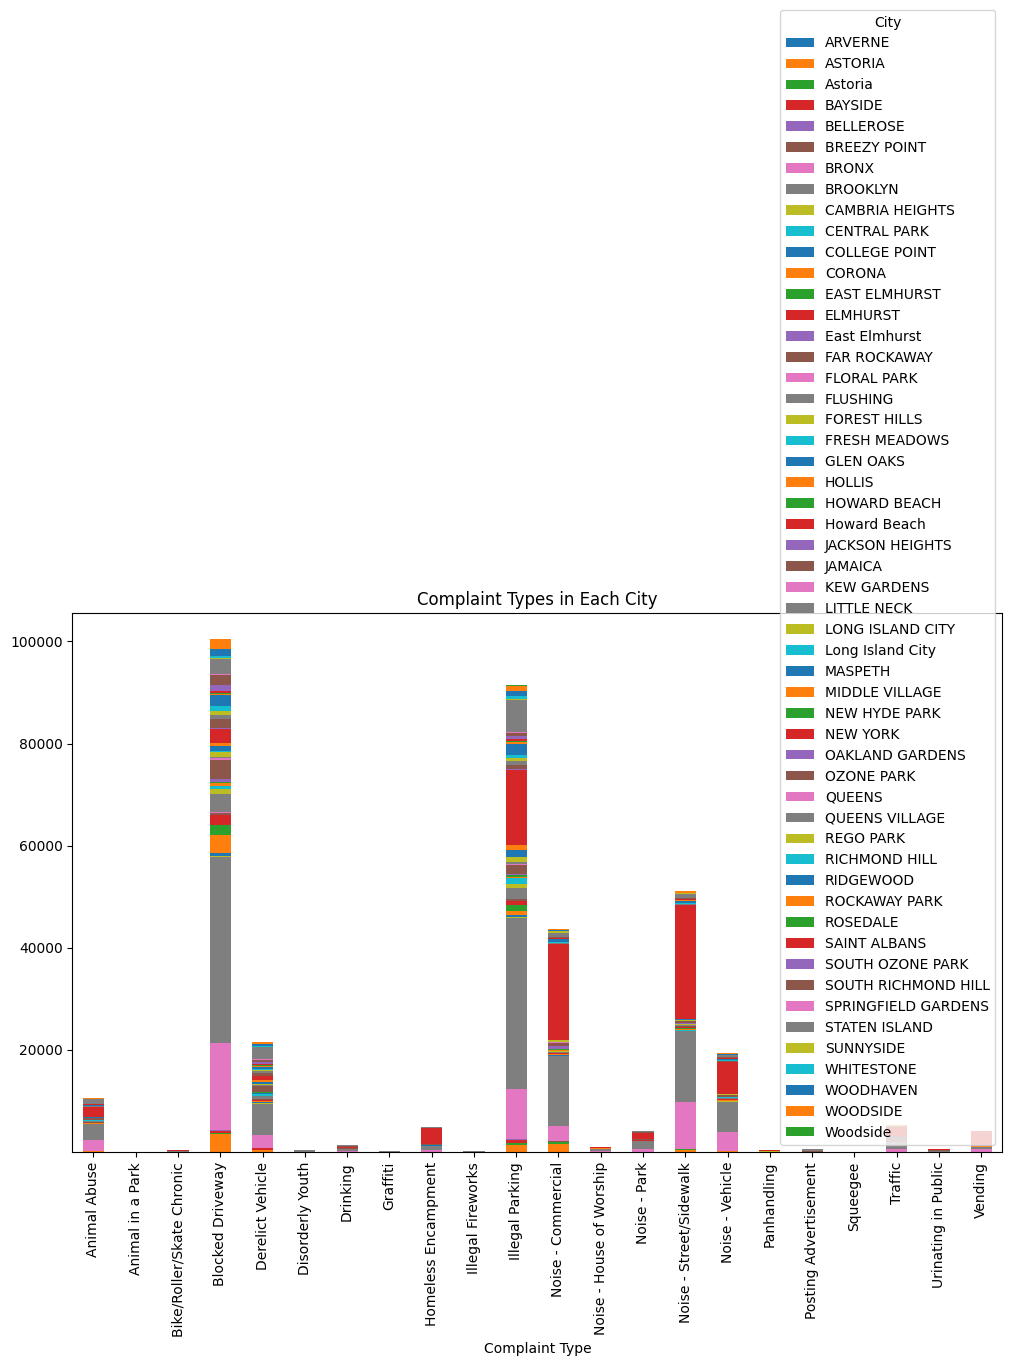

In [63]:
# 4.1Draw another chart that shows the types of complaints in each city in a single chart,
# where different colors show the different types of complaints
df_new.plot(kind ='bar', stacked = True, figsize = (12,7))
plt.title("Complaint Types in Each City")
plt.show()

In [64]:
# 4.2Sort the complaint types based on the average Request_Closing_Timegrouping them for 
#different locations
avg_time = df.groupby(['City', 'Complaint Type'])['Request_Closing_Time'].mean()
avg_time.sort_values().head(10)

City                 Complaint Type           
ARVERNE              Drinking                      859.0
RIDGEWOOD            Posting Advertisement         895.0
EAST ELMHURST        Bike/Roller/Skate Chronic     908.0
OZONE PARK           Illegal Fireworks            1191.0
QUEENS               Urinating in Public          1226.0
SOUTH RICHMOND HILL  Illegal Fireworks            1712.5
ARVERNE              Vending                      1735.0
SOUTH OZONE PARK     Illegal Fireworks            1821.0
KEW GARDENS          Posting Advertisement        1872.0
SUNNYSIDE            Graffiti                     2133.0
Name: Request_Closing_Time, dtype: float64

# 5.Average Response Time

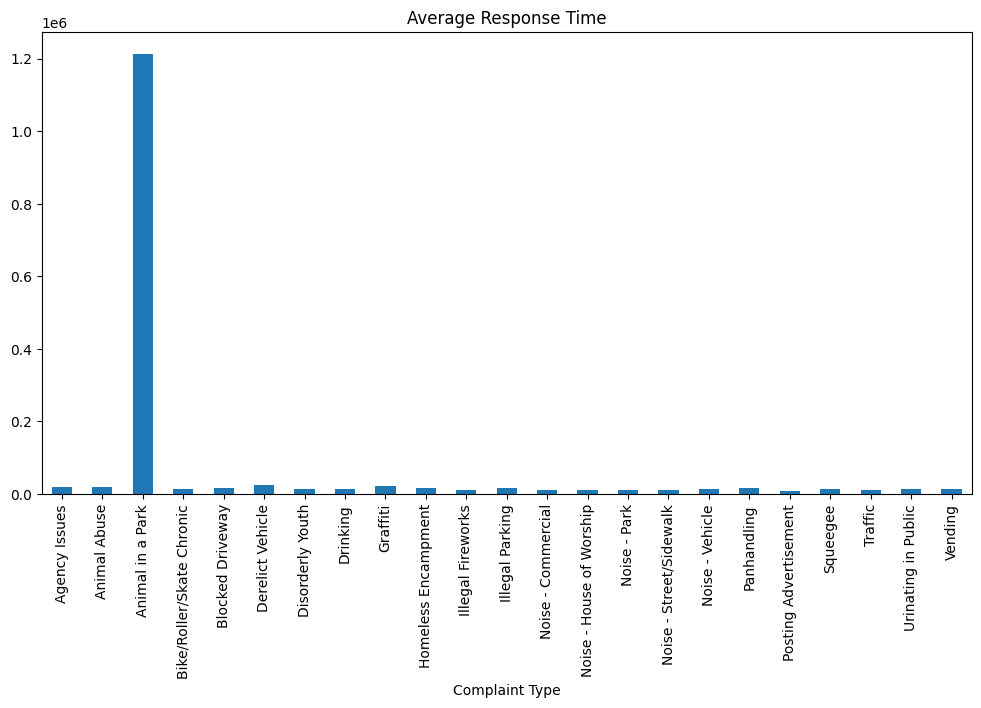

In [66]:
# 5.1Visualize the average of Request_Closing_Time 
avg = df.groupby('Complaint Type')['Request_Closing_Time'].mean()
avg.plot(kind='bar', figsize=(12,6))
plt.title("Average Response Time")
plt.show()

## 6. Identify the significant variables by performing statistical analysis using p-values

# 7.Perform a Kruskal-WallisH test

In [82]:
#7.1 Fail to reject H0: All sample distributions are equal 
#7.2 Reject H0: One or more sample distributions are not equal
from scipy.stats import kruskal

groups = df.groupby('Complaint Type')['Request_Closing_Time'].apply(list)

stat, p = kruskal(*groups[:5])  # using top 5 groups

print("P-value:", p)

if p < 0.05:
    print("Reject H0 → Not equal")
else:
    print("Fail to Reject H0 → Equal")

P-value: 2.0456061161139882e-13
Reject H0 → Not equal


# 8.📊 Observations:

📊 Observations:

- Most complaints are concentrated in major cities like New York, Brooklyn, and Queens.
- A few complaint types occur much more frequently than others, indicating common recurring issues.
- Missing values were mainly present in location-related columns and were handled properly.
- Response time varies significantly across different complaint types.
- Brooklyn shows a high density of complaints in specific geographic areas.
- The top 10 complaint types dominate the overall dataset distribution.
- Different cities show different patterns of complaint types.
- The average response time is not uniform across all complaint categories.
- The Kruskal-Wallis test indicates that response time is not the same for all complaint types (when p-value < 0.05).